# Prueba Técnica

Tienes dos archivos CSV: uno de **clientes** y otro de **pagos**.  

Los requisitos de la prueba técnica son los siguientes:

1. **Carga de datos**  
   - Cargar los DataFrames en variables o en un entorno que permita explorar la información.  
   - Realizar el **perfilamiento de datos** en ambos conjuntos.

2. **Categorización y etiquetado**  
   - Clasificar la información.  
   - Crear un pequeño **diccionario de datos** para su entrega en un ambiente productivo.  

3. **Separación de entornos**  
   - Mantener entornos de **desarrollo** y **producción** bien diferenciados.  
   - Asegurar que los cambios realizados en desarrollo para pruebas no afecten los valores en producción.  

4. **Output esperado** (Repositorio) 
   - Un **pipeline de funciones o componentes** que realice la ingesta, perfilamiento y ordenamiento de las dos tablas.  
   - Un **folder con el código utilizado**, ya sea en formato notebook o script, organizado para su entrega.  
   - Un **repositorio de código** que refleje exactamente lo entregado y que pueda replicarse en otro equipo, incluyendo ramas de **desarrollo** y **producción**.  
   - Se recomienda utilizar **Git** en local y **GitHub** en la web.  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns 

In [2]:
customers_df = pd.read_csv('data/customer_data.csv')
payments_df = pd.read_csv('data/payment_data.csv')

In [3]:
display(customers_df.head())
display(payments_df.head())

,label,id,fea_1,fea_2,fea_3,fea_4,fea_5,fea_6,fea_7,fea_8,fea_9,fea_10,fea_11
0,1,54982665,5,1245.5,3,77000.0,2,15,5,109,5,151300,244.948974
1,0,59004779,4,1277.0,1,113000.0,2,8,-1,100,3,341759,207.173840
2,0,58990862,7,1298.0,1,110000.0,2,11,-1,101,5,72001,1.000000
3,1,58995168,7,1335.5,1,151000.0,2,11,5,110,3,60084,1.000000
4,0,54987320,7,NaN,2,59000.0,2,11,5,108,4,450081,197.403141


,id,OVD_t1,OVD_t2,OVD_t3,OVD_sum,pay_normal,prod_code,prod_limit,update_date,new_balance,highest_balance,report_date
0,58987402,0,0,0,0,1,10,16500.0,04/12/2016,0.0,NaN,NaN
1,58995151,0,0,0,0,1,5,NaN,04/12/2016,588720.0,491100.0,NaN
2,58997200,0,0,0,0,2,5,NaN,04/12/2016,840000.0,700500.0,22/04/2016
3,54988608,0,0,0,0,3,10,37400.0,03/12/2016,8425.2,7520.0,25/04/2016
4,54987763,0,0,0,0,2,10,NaN,03/12/2016,15147.6,NaN,26/04/2016


### Infomación general de cada dataset

In [4]:
display(customers_df.info())
display(payments_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   label   1125 non-null   int64  
 1   id      1125 non-null   int64  
 2   fea_1   1125 non-null   int64  
 3   fea_2   976 non-null    float64
 4   fea_3   1125 non-null   int64  
 5   fea_4   1125 non-null   float64
 6   fea_5   1125 non-null   int64  
 7   fea_6   1125 non-null   int64  
 8   fea_7   1125 non-null   int64  
 9   fea_8   1125 non-null   int64  
 10  fea_9   1125 non-null   int64  
 11  fea_10  1125 non-null   int64  
 12  fea_11  1125 non-null   float64
dtypes: float64(3), int64(10)
memory usage: 114.4 KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8250 entries, 0 to 8249
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               8250 non-null   int64  
 1   OVD_t1           8250 non-null   int64  
 2   OVD_t2           8250 non-null   int64  
 3   OVD_t3           8250 non-null   int64  
 4   OVD_sum          8250 non-null   int64  
 5   pay_normal       8250 non-null   int64  
 6   prod_code        8250 non-null   int64  
 7   prod_limit       2132 non-null   float64
 8   update_date      8224 non-null   object 
 9   new_balance      8250 non-null   float64
 10  highest_balance  7841 non-null   float64
 11  report_date      7136 non-null   object 
dtypes: float64(3), int64(7), object(2)
memory usage: 773.6+ KB


None

### Análisis de núlos

In [5]:
display(customers_df.isnull().sum())
display(payments_df.isnull().sum())

label       0
id          0
fea_1       0
fea_2     149
fea_3       0
fea_4       0
fea_5       0
fea_6       0
fea_7       0
fea_8       0
fea_9       0
fea_10      0
fea_11      0
dtype: int64

id                    0
OVD_t1                0
OVD_t2                0
OVD_t3                0
OVD_sum               0
pay_normal            0
prod_code             0
prod_limit         6118
update_date          26
new_balance           0
highest_balance     409
report_date        1114
dtype: int64

### Porcentaje de nulos

In [6]:
display(customers_df.isnull().mean()[customers_df.isnull().sum() > 0] * 100)
display(payments_df.isnull().mean()[payments_df.isnull().sum() > 0] * 100)

fea_2    13.244444
dtype: float64

prod_limit         74.157576
update_date         0.315152
highest_balance     4.957576
report_date        13.503030
dtype: float64

### Resumen estadístico

In [7]:
display(customers_df.describe())
display(payments_df.describe())

,label,id,fea_1,fea_2,fea_3,fea_4,fea_5,fea_6,fea_7,fea_8,fea_9,fea_10,fea_11
count,1125.000000,1.125000e+03,1125.000000,976.000000,1125.000000,1.125000e+03,1125.000000,1125.000000,1125.000000,1125.000000,1125.000000,1125.000000,1125.000000
mean,0.200000,5.783677e+07,5.482667,1283.911373,2.333333,1.208836e+05,1.928889,10.872000,4.832889,100.802667,4.195556,164618.495111,134.999004
std,0.400178,1.817150e+06,1.383338,51.764022,0.878773,8.844523e+04,0.257125,2.676437,2.971182,11.988955,0.855679,152520.488281,112.616798
min,0.000000,5.498235e+07,1.000000,1116.500000,1.000000,1.500000e+04,1.000000,3.000000,-1.000000,64.000000,1.000000,60000.000000,1.000000
25%,0.000000,5.499050e+07,4.000000,1244.000000,1.000000,7.200000e+04,2.000000,8.000000,5.000000,90.000000,3.000000,60044.000000,1.000000
50%,0.000000,5.898975e+07,5.000000,1281.500000,3.000000,1.020000e+05,2.000000,11.000000,5.000000,105.000000,4.000000,72000.000000,173.205081
75%,0.000000,5.899799e+07,7.000000,1314.500000,3.000000,1.390000e+05,2.000000,11.000000,5.000000,111.000000,5.000000,151307.000000,202.484567
max,1.000000,5.900624e+07,7.000000,1481.000000,3.000000,1.200000e+06,2.000000,16.000000,10.000000,115.000000,5.000000,650070.000000,707.106781


,id,OVD_t1,OVD_t2,OVD_t3,OVD_sum,pay_normal,prod_code,prod_limit,new_balance,highest_balance
count,8.250000e+03,8250.000000,8250.000000,8250.000000,8250.000000,8250.000000,8250.000000,2132.000000,8.250000e+03,7.841000e+03
mean,5.782173e+07,0.249091,0.127152,0.369212,187.681697,14.526667,8.232000,85789.702205,1.054042e+05,2.192027e+05
std,1.822724e+06,1.250197,0.860046,2.900320,1804.232570,12.053627,3.533055,74345.828184,1.887704e+06,2.814536e+06
min,5.498235e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.100000,-4.030320e+04,5.010000e+02
25%,5.499050e+07,0.000000,0.000000,0.000000,0.000000,4.000000,6.000000,37400.000000,0.000000e+00,2.345300e+04
50%,5.898905e+07,0.000000,0.000000,0.000000,0.000000,11.000000,10.000000,68200.000000,0.000000e+00,4.404700e+04
75%,5.899655e+07,0.000000,0.000000,0.000000,0.000000,25.000000,10.000000,112200.000000,2.494800e+04,1.005000e+05
max,5.900624e+07,34.000000,34.000000,35.000000,31500.000000,36.000000,27.000000,660000.000000,1.632120e+08,1.800005e+08


### Conversion a formato de fecha

In [8]:
payments_df['report_date'] = pd.to_datetime(payments_df['report_date'] , dayfirst=True)
print(payments_df['report_date'].head())
payments_df['update_date'] = pd.to_datetime(payments_df['update_date'] , dayfirst=True)
print(payments_df['update_date'].head())

0          NaT
1          NaT
2   2016-04-22
3   2016-04-25
4   2016-04-26
Name: report_date, dtype: datetime64[ns]
0   2016-12-04
1   2016-12-04
2   2016-12-04
3   2016-12-03
4   2016-12-03
Name: update_date, dtype: datetime64[ns]


### Cantidad de filas duplicadas

In [9]:
display(customers_df.duplicated().sum())
display(payments_df.duplicated().sum())

np.int64(0)

np.int64(91)

### ID's duplicados

In [10]:
display(customers_df['id'].duplicated().sum())
#un cliente puede tener varios pagos
display(payments_df['id'].duplicated().sum())

np.int64(0)

np.int64(7125)

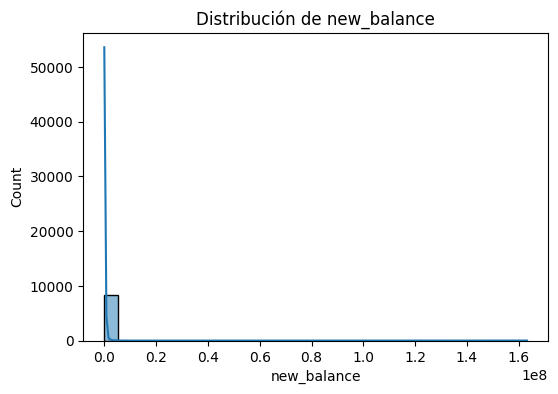

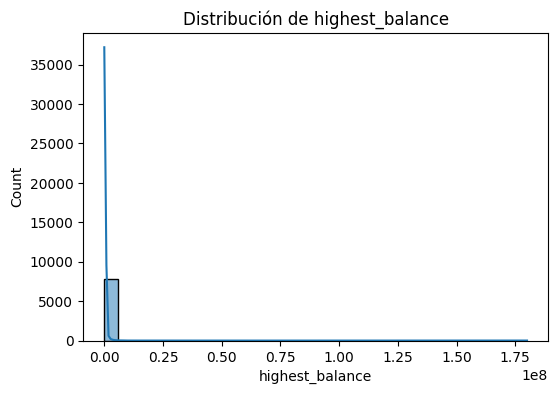

In [11]:
for col in ['new_balance', 'highest_balance']:  # Ajusta según tus columnas
    plt.figure(figsize=(6, 4))
    sns.histplot(payments_df[col], bins=30, kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

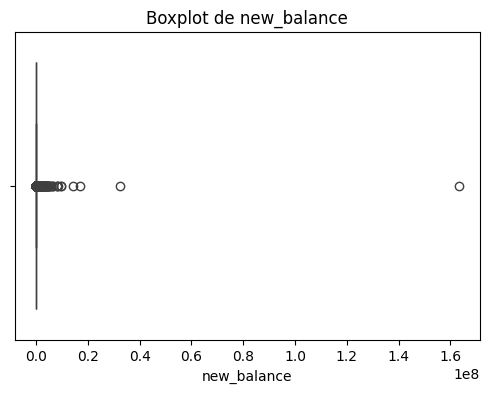

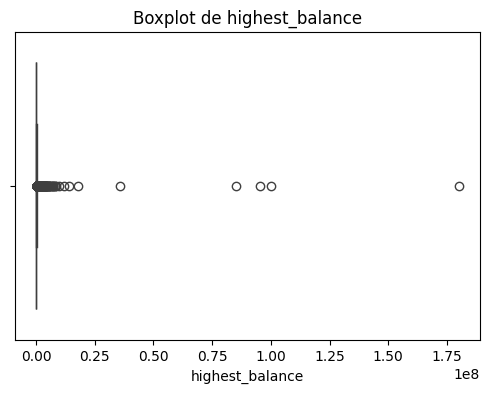

In [12]:
for col in ['new_balance', 'highest_balance']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=payments_df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

### Unión de las 2 tablas

In [13]:
merged_df = pd.merge(customers_df, payments_df, on='id', how='left')
display(merged_df.head())
merged_df.info()
display(merged_df.isnull().sum())
display(merged_df.isnull().mean()[merged_df.isnull().sum() > 0] * 100)
display(merged_df.duplicated().sum())
display(merged_df.describe())

,label,id,fea_1,fea_2,fea_3,fea_4,fea_5,fea_6,fea_7,fea_8,...,OVD_t2,OVD_t3,OVD_sum,pay_normal,prod_code,prod_limit,update_date,new_balance,highest_balance,report_date
0,1,54982665,5,1245.5,3,77000.0,2,15,5,109,...,0,0,0,9,10,60500.0,2015-01-31,6657.6,18934.0,2015-09-19
1,1,54982665,5,1245.5,3,77000.0,2,15,5,109,...,0,0,0,18,10,NaN,2009-04-28,153792.0,149387.0,2015-08-10
2,1,54982665,5,1245.5,3,77000.0,2,15,5,109,...,0,0,0,1,5,NaN,2009-03-30,0.0,150500.0,NaT
3,1,54982665,5,1245.5,3,77000.0,2,15,5,109,...,2,26,11906,6,10,NaN,2007-05-17,0.0,46371.0,2013-07-12
4,0,59004779,4,1277.0,1,113000.0,2,8,-1,100,...,0,0,0,4,6,NaN,2016-06-02,15120.0,21500.0,2016-04-19


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8250 entries, 0 to 8249
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   label            8250 non-null   int64         
 1   id               8250 non-null   int64         
 2   fea_1            8250 non-null   int64         
 3   fea_2            7222 non-null   float64       
 4   fea_3            8250 non-null   int64         
 5   fea_4            8250 non-null   float64       
 6   fea_5            8250 non-null   int64         
 7   fea_6            8250 non-null   int64         
 8   fea_7            8250 non-null   int64         
 9   fea_8            8250 non-null   int64         
 10  fea_9            8250 non-null   int64         
 11  fea_10           8250 non-null   int64         
 12  fea_11           8250 non-null   float64       
 13  OVD_t1           8250 non-null   int64         
 14  OVD_t2           8250 non-null   int64  

label                 0
id                    0
fea_1                 0
fea_2              1028
fea_3                 0
fea_4                 0
fea_5                 0
fea_6                 0
fea_7                 0
fea_8                 0
fea_9                 0
fea_10                0
fea_11                0
OVD_t1                0
OVD_t2                0
OVD_t3                0
OVD_sum               0
pay_normal            0
prod_code             0
prod_limit         6118
update_date          26
new_balance           0
highest_balance     409
report_date        1114
dtype: int64

fea_2              12.460606
prod_limit         74.157576
update_date         0.315152
highest_balance     4.957576
report_date        13.503030
dtype: float64

np.int64(91)

,label,id,fea_1,fea_2,fea_3,fea_4,fea_5,fea_6,fea_7,fea_8,...,OVD_t2,OVD_t3,OVD_sum,pay_normal,prod_code,prod_limit,update_date,new_balance,highest_balance,report_date
count,8250.000000,8.250000e+03,8250.000000,7222.000000,8250.000000,8.250000e+03,8250.000000,8250.000000,8250.000000,8250.000000,...,8250.000000,8250.000000,8250.000000,8250.000000,8250.000000,2132.000000,8224,8.250000e+03,7.841000e+03,7136
mean,0.168121,5.782173e+07,5.522667,1286.156813,2.319636,1.386712e+05,1.940848,11.013939,4.881091,100.026303,...,0.127152,0.369212,187.681697,14.526667,8.232000,85789.702205,2012-02-12 10:27:11.906614528,1.054042e+05,2.192027e+05,2014-06-23 22:25:21.524663296
min,0.000000,5.498235e+07,1.000000,1116.500000,1.000000,1.500000e+04,1.000000,3.000000,-1.000000,64.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.100000,1988-07-19 00:00:00,-4.030320e+04,5.010000e+02,1996-02-24 00:00:00
25%,0.000000,5.499050e+07,4.000000,1248.500000,1.000000,7.700000e+04,2.000000,8.000000,5.000000,90.000000,...,0.000000,0.000000,0.000000,4.000000,6.000000,37400.000000,2009-02-10 06:00:00,0.000000e+00,2.345300e+04,2013-09-22 00:00:00
50%,0.000000,5.898905e+07,5.000000,1283.000000,3.000000,1.110000e+05,2.000000,11.000000,5.000000,105.000000,...,0.000000,0.000000,0.000000,11.000000,10.000000,68200.000000,2013-06-17 12:00:00,0.000000e+00,4.404700e+04,2015-09-21 00:00:00
75%,0.000000,5.899655e+07,7.000000,1317.500000,3.000000,1.510000e+05,2.000000,12.000000,5.000000,110.000000,...,0.000000,0.000000,0.000000,25.000000,10.000000,112200.000000,2015-01-27 00:00:00,2.494800e+04,1.005000e+05,2016-01-29 00:00:00
max,1.000000,5.900624e+07,7.000000,1481.000000,3.000000,1.200000e+06,2.000000,16.000000,10.000000,115.000000,...,34.000000,35.000000,31500.000000,36.000000,27.000000,660000.000000,2016-12-04 00:00:00,1.632120e+08,1.800005e+08,2016-12-06 00:00:00
std,0.373997,1.822724e+06,1.388358,52.002429,0.887414,1.081565e+05,0.235922,2.694611,3.031902,12.540081,...,0.860046,2.900320,1804.232570,12.053627,3.533055,74345.828184,NaN,1.887704e+06,2.814536e+06,NaN


#### Clientes con pagos registrados:

In [14]:
common_ids = customers_df['id'].isin(payments_df['id']).sum()
total_customers = customers_df.shape[0]

print(f"Clientes con pagos registrados: {common_ids} de {total_customers} ({(common_ids/total_customers)*100:.2f}%)")


Clientes con pagos registrados: 1125 de 1125 (100.00%)


### Pagos sin cliente asociado

In [15]:
payments_without_customers = payments_df[~payments_df['id'].isin(customers_df['id'])]
print(f"Pagos sin cliente asociado: {payments_without_customers.shape[0]}")


Pagos sin cliente asociado: 0


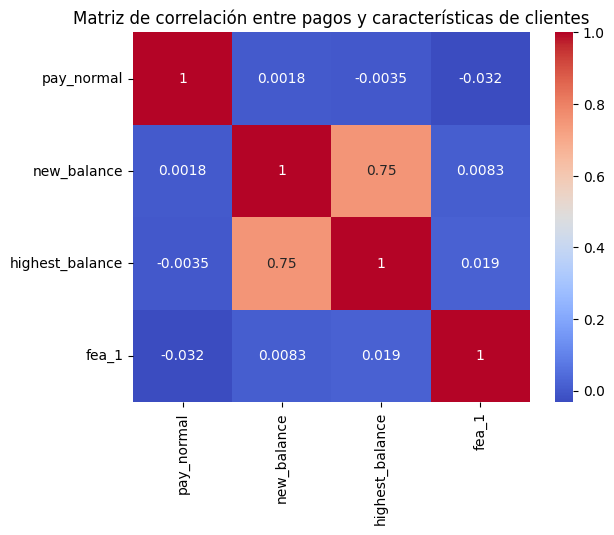

In [16]:
correlation = merged_df[['pay_normal', 'new_balance', 'highest_balance', 'fea_1']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación entre pagos y características de clientes")
plt.show()


### Diccionario de datos tabla Customer_data

| Nombre de la columna | Descripción | Tipo de dato | Ejemplo |
|---------------------|-------------|------------|---------|
| `label`            | Etiqueta de clasificación del cliente (posible objetivo de modelo) | `int` (0 o 1) | 1 |
| `id`               | Identificador único del cliente (relacionado con pagos) | `int` | 54982665 |
| `fea_1`            | Categoría del cliente (posible segmentación) | `int` | 5 |
| `fea_2`            | Valor asociado a la cuenta del cliente (posible monto o scoring) | `float` (puede ser nulo) | 1245.5 |
| `fea_3`            | Código de comportamiento del cliente | `int` | 3 |
| `fea_4`            | Monto relacionado con la cuenta del cliente | `float` | 77000.0 |
| `fea_5`            | Tipo de cuenta o producto financiero | `int` | 2 |
| `fea_6`            | Número de interacciones recientes del cliente | `int` | 15 |
| `fea_7`            | Indicador de comportamiento (puede incluir valores negativos) | `int` | 5 |
| `fea_8`            | Código de estado del cliente | `int` | 109 |
| `fea_9`            | Categoría adicional de clasificación | `int` | 5 |
| `fea_10`           | Monto máximo registrado en la cuenta | `int` | 151300 |
| `fea_11`           | Factor de ajuste o puntuación asociada al cliente | `float` | 244.95 |

## Notas y Posibles Acciones:
- `id` es la clave principal y se relaciona con `id` en la tabla de pagos.  
- `fea_2` tiene valores nulos, sería útil analizar si deben imputarse o eliminarse.  
- `label` podría representar si un cliente es "bueno" o "malo" en términos de comportamiento financiero.  
- Se podría explorar si `fea_1`, `fea_3`, `fea_5`, `fea_7`, `fea_8` y `fea_9` representan categorías o códigos que deberían mapearse a valores descriptivos. 

### Diccionario de datos tabla Payment_data

| Nombre de la columna  | Descripción | Tipo de dato | Ejemplo |
|----------------------|-------------|------------|---------|
| `id`                | Identificador único del cliente (relacionado con la tabla de clientes) | `int` | 58987402 |
| `OVD_t1`            | Indicador de mora en el período t1 (0 = sin mora, otro valor = con mora) | `int` | 0 |
| `OVD_t2`            | Indicador de mora en el período t2 | `int` | 0 |
| `OVD_t3`            | Indicador de mora en el período t3 | `int` | 0 |
| `OVD_sum`           | Suma total de los períodos en mora | `int` | 0 |
| `pay_normal`        | Indicador de pago normal (1 = pago realizado según lo esperado) | `int` | 1 |
| `prod_code`         | Código del producto financiero asociado al pago | `int` | 10 |
| `prod_limit`        | Límite de crédito o monto máximo disponible para el producto | `float` (puede ser nulo) | 16500.0 |
| `update_date`       | Fecha de última actualización del registro | `object` (fecha) | 04/12/2016 |
| `new_balance`       | Saldo actualizado después del último pago | `float` | 0.0 |
| `highest_balance`   | Saldo más alto registrado en la cuenta | `float` (puede ser nulo) | NaN |
| `report_date`       | Fecha de generación del reporte de pagos | `object` (fecha, puede ser nula) | NaN |

## 📌 Notas y Posibles Acciones:
- `id` es la clave primaria y se relaciona con la tabla de clientes.
- `OVD_t1`, `OVD_t2`, `OVD_t3` y `OVD_sum` parecen indicar el estado de mora en distintos períodos.
- `prod_limit` y `highest_balance` contienen valores nulos, analizar si deben imputarse o descartarse.
- `update_date` y `report_date` están en formato de fecha, se convertirán a `datetime`.
- `report_date` tiene una cantidad considerable de valores nulos (1114), revisar si son registros antiguos o incompletos.

### Tabla Clientes Organizada por fea_10 y label

In [ ]:
sorted_customers_df = customers_df.sort_values(by=['fea_10', 'label'], ascending=[False, True])
sorted_customers_df.head()


,label,id,fea_1,fea_2,fea_3,fea_4,fea_5,fea_6,fea_7,fea_8,fea_9,fea_10,fea_11
96,0,58995669,7,NaN,3,35000.0,2,12,-1,86,3,650070,161.854873
56,0,54982353,1,1130.0,2,1000000.0,2,4,-1,100,5,650018,1.000000
813,0,58982397,1,1293.5,1,500000.0,2,4,9,105,5,650005,1.000000
399,0,54986897,7,1367.0,3,234000.0,2,11,5,113,5,591044,1.000000
412,0,54987682,7,1290.5,1,119000.0,2,11,9,114,4,591017,1.000000


### Tabla Pagos Organizada por mora, mayor saldo, fecha más reciente


In [20]:
sorted_payments_df = payments_df.sort_values(by=['OVD_sum', 'new_balance', 'update_date'], ascending=[False, False, False])
sorted_payments_df.head()


,id,OVD_t1,OVD_t2,OVD_t3,OVD_sum,pay_normal,prod_code,prod_limit,update_date,new_balance,highest_balance,report_date
6215,54982353,0,0,35,31500,0,10,12100.0,2008-12-27,12142.8,10619.0,2009-07-14
7073,54988422,0,0,35,31500,1,10,NaN,2007-07-16,0.0,47246.0,2010-01-21
6185,54989873,0,0,35,31300,1,5,NaN,2009-01-25,0.0,100500.0,2014-11-19
6975,54982721,0,0,34,30600,1,13,NaN,2007-09-09,0.0,54500.0,2014-06-06
7639,58990934,0,0,34,30600,1,10,NaN,2006-02-02,-1.2,64096.0,2013-08-07


### Análisis de morosidad

In [22]:
# Definir condiciones
condiciones = [
    (payments_df['OVD_sum'] == 0) & (payments_df['pay_normal'] > 0),  # Buen pagador
    (payments_df['OVD_sum'] > 0) & (payments_df['pay_normal'] > 0),   # Moroso leve
    (payments_df['OVD_sum'] > 0) & (payments_df['pay_normal'] == 0)   # Moroso severo
]

# Etiquetas de clasificación
categorias = ['Buen Pagador', 'Moroso Leve', 'Moroso Severo']

# Crear nueva columna
payments_df['categoria_morosidad'] = np.select(condiciones, categorias, default='Desconocido')

# Ver resultados
payments_df[['id', 'OVD_sum', 'pay_normal', 'categoria_morosidad']].head(10)

,id,OVD_sum,pay_normal,categoria_morosidad
6215,54982353,31500,0,Moroso Severo
7073,54988422,31500,1,Moroso Leve
6185,54989873,31300,1,Moroso Leve
6975,54982721,30600,1,Moroso Leve
7639,58990934,30600,1,Moroso Leve
7277,58990934,30312,1,Moroso Leve
5927,58984653,29922,1,Moroso Leve
7401,58982909,29890,1,Moroso Leve
6812,54989873,29700,2,Moroso Leve
6494,58986716,29645,1,Moroso Leve


In [23]:
payments_df['categoria_morosidad'].value_counts()

categoria_morosidad
Buen Pagador     7064
Moroso Leve       901
Desconocido       266
Moroso Severo      19
Name: count, dtype: int64

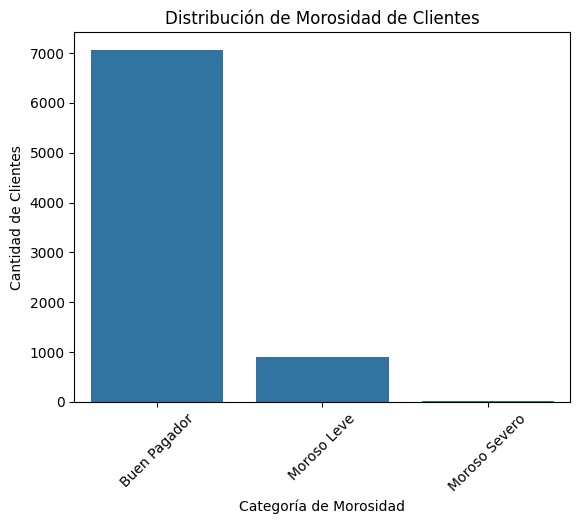

In [25]:
sns.countplot(data=payments_df, x='categoria_morosidad', order=['Buen Pagador', 'Moroso Leve', 'Moroso Severo'])
plt.title("Distribución de Morosidad de Clientes")
plt.xlabel("Categoría de Morosidad")
plt.ylabel("Cantidad de Clientes")
plt.xticks(rotation=45)
plt.show()